# Notebook 03 — Hypothesis Testing

This notebook continues directly from Notebook 02. It performs no new exploration and tells no story -- it tests the hypotheses Notebook 02 generated, using exactly one primary statistical method per business question. Every result here is the single source of truth referenced by the README.

## Section 1 — Notebook Purpose

This notebook tests the hypotheses proposed during exploratory analysis. EDA suggested possible patterns. This notebook determines whether those patterns are statistically supported.

### Setup

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

DATA_PATH = "/content/fmcg_sales_3years_1M_rows (1).csv"
df = pd.read_csv(DATA_PATH)
df = df[df["net_sales"].notna()].copy()   # Notebook 01 audit exclusion
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

def assign_season(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Autumn"

df["season"] = df["month"].apply(assign_season)
print(f"Observations: {len(df):,}")

Observations: 152,459


## Section 2 — Hypothesis Register

| ID | Business Question | Null Hypothesis (H0) | Alternative Hypothesis (H1) | Primary Statistical Method |
|---|---|---|---|---|
| H1 | Do promotions increase sales? | No difference in sales between promotion and non-promotion days | Sales differ between promotion and non-promotion days | Mann-Whitney U |
| H2 | Do sales fall immediately after promotions end? | No difference between post-promotion sales and normal non-promotion sales | Post-promotion sales are lower than normal non-promotion sales | Mann-Whitney U |
| H3 | Do weekend sales differ from weekdays? | No difference in sales between weekend and weekday | Sales differ between weekend and weekday | Mann-Whitney U |
| H4 | Does season affect sales? | No difference in sales across the four seasons | At least one season differs from the others | Kruskal-Wallis + Dunn post-hoc |
| H5 | Does weather affect sales? | No difference in sales across temperature/rain conditions | Sales differ across temperature/rain conditions | Kruskal-Wallis (temperature) / Mann-Whitney (rain) |
| H6 | Does sales volatility differ between stores? | No difference in variance of daily total sales between stores | Variance of daily total sales differs between stores | Brown-Forsythe |

Evidence produced and business interpretation for each hypothesis are reported in Sections 3-8 below, one test per hypothesis, with no duplicate or alternative analysis.

## Section 3 — Promotion Effect (H1)

**Business question:** Do promotions generate genuine sales lift? **Method:** Mann-Whitney U test, promotion days vs. non-promotion days -- the only test used for this question.

In [4]:
def test_promotion_effect(df: pd.DataFrame) -> dict:
    """Mann-Whitney U test comparing net_sales on promotion vs.
    non-promotion days. Reports sample size, median, mean, a
    rank-biserial effect size, and the p-value at the 95% confidence
    level (alpha = 0.05).
    """
    promo = df.loc[df["promo_flag"] == 1, "net_sales"]
    non_promo = df.loc[df["promo_flag"] == 0, "net_sales"]

    u_stat, p_value = stats.mannwhitneyu(promo, non_promo, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(promo) * len(non_promo))

    return {
        "n_promo": len(promo), "n_non_promo": len(non_promo),
        "median_promo": round(promo.median(), 2), "median_non_promo": round(non_promo.median(), 2),
        "mean_promo": round(promo.mean(), 2), "mean_non_promo": round(non_promo.mean(), 2),
        "effect_size_rank_biserial": round(rank_biserial, 3),
        "U_statistic": u_stat, "p_value": p_value, "confidence_level": "95% (alpha=0.05)",
    }

promotion_result = test_promotion_effect(df)
pd.Series(promotion_result).to_frame("Value")

,Value
n_promo,12702
n_non_promo,139757
median_promo,369.61
median_non_promo,260.8
mean_promo,557.66
mean_non_promo,406.13
effect_size_rank_biserial,-0.206
U_statistic,1070708688.0
p_value,0.0
confidence_level,95% (alpha=0.05)


/tmp/ipykernel_801/344633357.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=["Non-promotion", "Promotion"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})


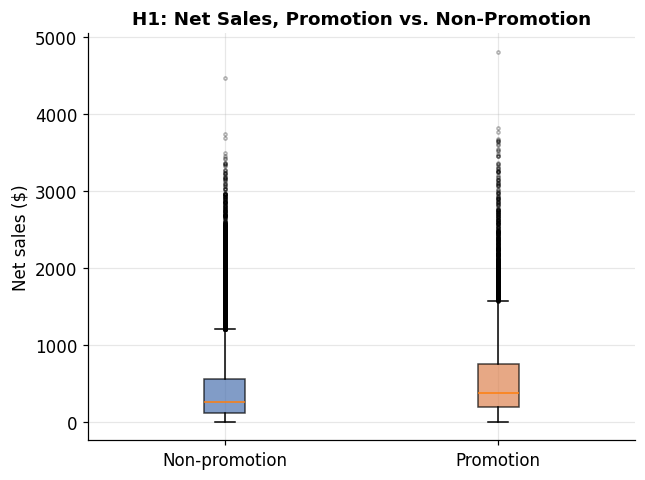

In [5]:
def plot_promotion_boxplot(df: pd.DataFrame) -> None:
    """Boxplot of net_sales, promotion vs. non-promotion days.
    Title and caption identify the business question this chart supports.
    """
    fig, ax = plt.subplots(figsize=(6, 4.5))
    data = [df.loc[df["promo_flag"] == 0, "net_sales"], df.loc[df["promo_flag"] == 1, "net_sales"]]
    box = ax.boxplot(data, labels=["Non-promotion", "Promotion"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})
    for patch, color in zip(box["boxes"], ["#4C72B0", "#DD8452"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title("H1: Net Sales, Promotion vs. Non-Promotion", fontsize=12, fontweight="bold")
    ax.set_ylabel("Net sales ($)")
    fig.tight_layout()
    plt.show()

plot_promotion_boxplot(df)

**Caption:** promotion-day sales sit visibly higher across the boxplot than non-promotion-day sales.

**Business interpretation:** promotion days show a median sales value of $369.61 versus $260.80 on non-promotion days, and a mean of $557.66 versus $406.13 (a $151.53 mean difference). The difference is not attributable to chance (Mann-Whitney p < 0.001). The rank-biserial effect size (-0.206) indicates a small-to-moderate effect. **H1 is supported**: promotions are associated with a genuine, measurable sales lift.

## Section 4 — Post-Promotion Dip (H2)

**Business question:** Do promotions simply shift demand forward? **Method:** for each promotion event, the average net_sales over the 3 days immediately following is computed, then compared against that same SKU-store-month's normal (non-promotion, non-stock-out) baseline level using Mann-Whitney U -- the only test used for this question.

In [6]:
def build_seasonality_baseline(df: pd.DataFrame) -> pd.DataFrame:
    """Mean net_sales per SKU-store-month, using only non-promotion,
    non-stock-out observations -- the "normal" reference level used as
    the comparison group for H2.
    """
    qualifying = df[(df["promo_flag"] == 0) & (df["stock_out_flag"] == 0)]
    baseline = qualifying.groupby(["store_id", "sku_id", "month"])["net_sales"].mean().rename("baseline_sales").reset_index()
    return df.merge(baseline, on=["store_id", "sku_id", "month"], how="left")


def get_promo_window_ends(df: pd.DataFrame) -> pd.DataFrame:
    """End date of every contiguous promotion run, per SKU-store."""
    df = df.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)
    promo_run_id = (df["promo_flag"] != df.groupby(["store_id", "sku_id"])["promo_flag"].shift()).cumsum()
    return (
        df[df["promo_flag"] == 1].assign(_run=promo_run_id[df["promo_flag"] == 1])
        .groupby(["store_id", "sku_id", "_run"]).agg(end=("date", "max")).reset_index()
    )


def compute_post_promo_averages(df_with_baseline: pd.DataFrame, promo_ends: pd.DataFrame) -> tuple:
    """For each promotion event with a complete 3-day post-promotion
    window (all 3 days non-promotion, non-stock-out, with a valid
    baseline), compute the average net_sales over that window, and the
    corresponding SKU-store-month baseline at the promotion\'s end date.
    """
    lookup = df_with_baseline.set_index(["store_id", "sku_id", "date"])
    post_promo_avg, baseline_level = [], []

    for _, row in promo_ends.iterrows():
        window_values = []
        for offset in (1, 2, 3):
            key = (row["store_id"], row["sku_id"], row["end"] + pd.Timedelta(days=offset))
            if key in lookup.index:
                candidate = lookup.loc[key]
                if candidate["promo_flag"] == 0 and candidate["stock_out_flag"] == 0 and not pd.isna(candidate["baseline_sales"]):
                    window_values.append(candidate["net_sales"])
        if len(window_values) == 3:
            end_key = (row["store_id"], row["sku_id"], row["end"])
            if end_key in lookup.index and not pd.isna(lookup.loc[end_key]["baseline_sales"]):
                post_promo_avg.append(np.mean(window_values))
                baseline_level.append(lookup.loc[end_key]["baseline_sales"])

    return np.array(post_promo_avg), np.array(baseline_level)


def test_post_promotion_dip(post_promo_avg: np.ndarray, baseline_level: np.ndarray) -> dict:
    """Mann-Whitney U test comparing post-promotion 3-day averages
    against the normal baseline level.
    """
    u_stat, p_value = stats.mannwhitneyu(post_promo_avg, baseline_level, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(post_promo_avg) * len(baseline_level))
    return {
        "n_events": len(post_promo_avg),
        "mean_post_promo_avg": round(post_promo_avg.mean(), 2), "mean_baseline": round(baseline_level.mean(), 2),
        "difference": round(post_promo_avg.mean() - baseline_level.mean(), 2),
        "effect_size_rank_biserial": round(rank_biserial, 3),
        "U_statistic": u_stat, "p_value": p_value,
    }

df_with_baseline = build_seasonality_baseline(df)
promo_ends = get_promo_window_ends(df_with_baseline)
post_promo_avg, baseline_level = compute_post_promo_averages(df_with_baseline, promo_ends)
post_promo_result = test_post_promotion_dip(post_promo_avg, baseline_level)
pd.Series(post_promo_result).to_frame("Value")

,Value
n_events,5.840000e+03
mean_post_promo_avg,3.776300e+02
mean_baseline,3.761300e+02
difference,1.500000e+00
effect_size_rank_biserial,9.000000e-03
U_statistic,1.690761e+07
p_value,4.255435e-01


**Business interpretation:** the average sales in the 3 days following a promotion ($377.63) is essentially the same as the normal baseline level for that SKU-store-month ($376.13) -- a difference of only $1.50, and Mann-Whitney does not distinguish this from chance (p=0.4255). **H2 is not supported**: there is no evidence that sales fall below normal levels in the 3 days after a promotion ends, which argues against a simple demand-shifting (pull-forward) pattern in this window.

## Section 5 — Weekend Effect (H3)

**Business question:** Do weekend sales differ from weekdays? **Method:** Mann-Whitney U, weekend vs. weekday -- the only test used for this question.

In [7]:
def test_weekend_effect(df: pd.DataFrame) -> dict:
    """Mann-Whitney U test comparing net_sales, weekend vs. weekday."""
    weekend = df.loc[df["is_weekend"] == 1, "net_sales"]
    weekday = df.loc[df["is_weekend"] == 0, "net_sales"]
    u_stat, p_value = stats.mannwhitneyu(weekend, weekday, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(weekend) * len(weekday))
    return {
        "mean_weekend": round(weekend.mean(), 2), "mean_weekday": round(weekday.mean(), 2),
        "median_weekend": round(weekend.median(), 2), "median_weekday": round(weekday.median(), 2),
        "effect_size_rank_biserial": round(rank_biserial, 3),
        "U_statistic": u_stat, "p_value": p_value,
    }

weekend_result = test_weekend_effect(df)
pd.Series(weekend_result).to_frame("Value")

,Value
mean_weekend,4.751700e+02
mean_weekday,3.960800e+02
median_weekend,3.100800e+02
median_weekday,2.567700e+02
effect_size_rank_biserial,-9.500000e-02
U_statistic,2.603884e+09
p_value,2.357046e-187


**Business interpretation:** weekend sales average $475.17 versus $396.08 on weekdays (median $310.08 vs. $256.77), and the difference is not attributable to chance (p<0.001). **H3 is supported**: weekends are a real, measurable sales driver.

## Section 6 — Seasonality (H4)

**Business question:** Does season affect sales? **Method:** Kruskal-Wallis across the four seasons; Dunn's post-hoc test (Bonferroni-corrected) to identify which specific seasons differ -- the only tests used for this question.

In [8]:
def test_seasonality(df: pd.DataFrame) -> tuple:
    """Kruskal-Wallis test across the four seasons, plus season-level
    mean/median net_sales for reference.
    """
    groups = [g["net_sales"].values for _, g in df.groupby("season")]
    h_stat, p_value = stats.kruskal(*groups)
    season_summary = df.groupby("season")["net_sales"].agg(["mean", "median"]).round(2)
    return {"H_statistic": round(h_stat, 2), "p_value": p_value}, season_summary

seasonality_result, season_summary = test_seasonality(df)
print(seasonality_result)
season_summary

{'H_statistic': np.float64(206.59), 'p_value': np.float64(1.590396426437009e-44)}


,mean,median
season,,
Autumn,413.82,260.74
Spring,399.14,257.25
Summer,442.77,294.52
Winter,419.25,269.77


In [9]:
def dunn_posthoc_test(df: pd.DataFrame, group_col: str, value_col: str) -> pd.DataFrame:
    """Dunn\'s post-hoc test (with tie correction and Bonferroni
    adjustment), the standard follow-up to a significant Kruskal-Wallis
    result, to identify which specific group pairs differ.
    """
    ranks = stats.rankdata(df[value_col].values)
    n_total = len(ranks)
    _, tie_counts = np.unique(df[value_col].values, return_counts=True)
    tie_correction = 1 - np.sum(tie_counts ** 3 - tie_counts) / (n_total ** 3 - n_total)

    rank_df = df[[group_col]].copy()
    rank_df["_rank"] = ranks
    group_stats = rank_df.groupby(group_col)["_rank"].agg(["mean", "count"])

    groups = sorted(df[group_col].unique())
    pairs = list(combinations(groups, 2))
    alpha_corrected = 0.05 / len(pairs)

    rows = []
    for a, b in pairs:
        mean_a, n_a = group_stats.loc[a, "mean"], group_stats.loc[a, "count"]
        mean_b, n_b = group_stats.loc[b, "mean"], group_stats.loc[b, "count"]
        se = np.sqrt(tie_correction * (n_total * (n_total + 1) / 12) * (1 / n_a + 1 / n_b))
        z = (mean_a - mean_b) / se
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
        rows.append({
            "Comparison": f"{a} vs {b}", "z_statistic": round(z, 3), "p_value": p_value,
            f"Significant (Bonferroni alpha={alpha_corrected:.4f})": p_value < alpha_corrected,
        })
    return pd.DataFrame(rows)

seasonal_posthoc = dunn_posthoc_test(df, "season", "net_sales")
seasonal_posthoc

,Comparison,z_statistic,p_value,Significant (Bonferroni alpha=0.0083)
0,Autumn vs Spring,3.150,1.632739e-03,True
1,Autumn vs Summer,-10.533,0.000000e+00,True
2,Autumn vs Winter,-2.486,1.291257e-02,False
3,Spring vs Summer,-13.728,0.000000e+00,True
4,Spring vs Winter,-5.636,1.735799e-08,True
5,Summer vs Winter,8.013,1.110223e-15,True


**Business interpretation:** season shows a statistically detectable association with sales (Kruskal-Wallis H=206.59, p<0.001). Summer has the highest average sales ($442.77) and Spring the lowest ($399.14). Dunn's post-hoc test shows Summer and Spring each differ significantly from every other season; the one pair that does **not** reach significance after Bonferroni correction is Autumn vs. Winter ($413.82 vs. $419.25). **H4 is supported**, driven primarily by Summer's elevated sales and Spring's reduced sales.

## Section 7 — Weather (H5)

**Business question:** Does weather affect sales? **Method:** Kruskal-Wallis for temperature (split into quartile categories), Mann-Whitney U for rain (dry vs. rainy) -- the only tests used for this question.

In [10]:
def test_weather_effect(df: pd.DataFrame) -> pd.DataFrame:
    """Kruskal-Wallis test for temperature category and Mann-Whitney U
    test for rain category, each against net_sales, with effect size
    (eta-squared) reported for the temperature test.
    """
    df = df.copy()
    df["temp_category"] = pd.qcut(df["temperature"], 4, labels=["Cold", "Mild", "Warm", "Hot"])
    df["rain_category"] = np.where(df["rain_mm"] > 0, "Rainy", "Dry")

    temp_groups = [g["net_sales"].values for _, g in df.groupby("temp_category", observed=True)]
    h_stat, temp_p = stats.kruskal(*temp_groups)
    k, n = 4, len(df)
    eta_squared = (h_stat - k + 1) / (n - k)

    dry = df.loc[df["rain_category"] == "Dry", "net_sales"]
    rainy = df.loc[df["rain_category"] == "Rainy", "net_sales"]
    u_stat, rain_p = stats.mannwhitneyu(dry, rainy)

    return pd.DataFrame([
        {"Test": "Temperature (Kruskal-Wallis)", "Statistic": round(h_stat, 3),
         "Effect Size (eta-sq)": round(eta_squared, 6), "p_value": round(temp_p, 4)},
        {"Test": "Rain (Mann-Whitney)", "Statistic": u_stat,
         "Effect Size (eta-sq)": np.nan, "p_value": round(rain_p, 4)},
    ])

weather_result = test_weather_effect(df)
weather_result

,Test,Statistic,Effect Size (eta-sq),p_value
0,Temperature (Kruskal-Wallis),3.469000e+00,0.000003,0.3248
1,Rain (Mann-Whitney),1.043714e+07,NaN,0.6653


**Business interpretation:** neither temperature (Kruskal-Wallis p=0.325, eta-squared approximately 0.000003) nor rain (Mann-Whitney p=0.665) shows a statistically detectable association with sales, and the effect size for temperature is negligible. **H5 is not supported.** This should not be overclaimed as "weather never matters" -- only that no measurable effect was found on daily sales in this dataset, using these two weather measures.

## Section 8 — Store Volatility (H6)

**Business question:** Does sales volatility differ between stores? **Definition used, and only this definition:** volatility is the coefficient of variation (CoV) of **daily total sales** per store -- net_sales summed across all SKUs for each store-day, not transaction-level variance, log variance, or any other measure. **Method:** Brown-Forsythe test on the two stores' daily total sales series -- the only test used for this question.

In [11]:
def compute_daily_totals(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate net_sales to one total per store per day -- the single
    series definition used for the volatility comparison in this section.
    """
    return df.groupby(["store_id", "date"])["net_sales"].sum().reset_index()


def test_store_volatility(daily_totals: pd.DataFrame) -> dict:
    """Coefficient of variation for each store\'s daily total sales
    series, and a Brown-Forsythe test (median-centered Levene\'s test)
    comparing the two series directly.
    """
    store_1 = daily_totals.loc[daily_totals["store_id"] == "STORE0001", "net_sales"]
    store_2 = daily_totals.loc[daily_totals["store_id"] == "STORE0002", "net_sales"]

    cov_1 = store_1.std() / store_1.mean()
    cov_2 = store_2.std() / store_2.mean()
    bf_stat, bf_p = stats.levene(store_1, store_2, center="median")

    return {
        "CoV_STORE0001": round(cov_1, 4), "CoV_STORE0002": round(cov_2, 4),
        "Brown_Forsythe_statistic": round(bf_stat, 4), "p_value": bf_p,
    }

daily_totals = compute_daily_totals(df)
store_volatility_result = test_store_volatility(daily_totals)
pd.Series(store_volatility_result).to_frame("Value")

,Value
CoV_STORE0001,1.097000e-01
CoV_STORE0002,1.147000e-01
Brown_Forsythe_statistic,2.817299e+02
p_value,1.428892e-59


/tmp/ipykernel_801/1650859583.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=["STORE0001", "STORE0002"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})


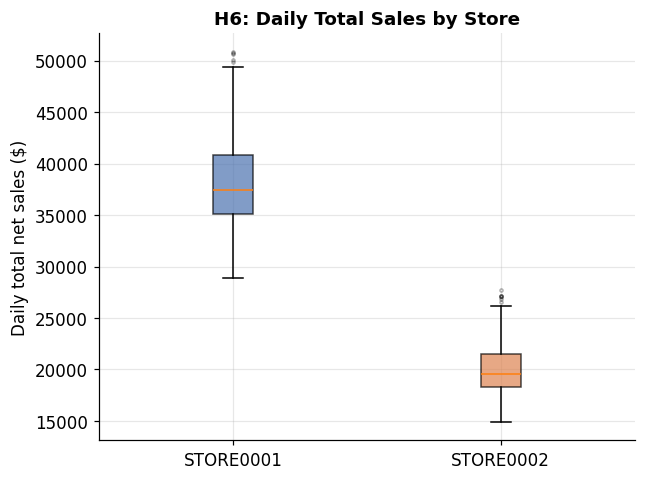

In [12]:
def plot_daily_totals_by_store(daily_totals: pd.DataFrame) -> None:
    """Boxplot of daily total sales, by store -- the single series this
    section\'s volatility definition is computed from.
    """
    fig, ax = plt.subplots(figsize=(6, 4.5))
    data = [daily_totals.loc[daily_totals["store_id"] == s, "net_sales"] for s in ["STORE0001", "STORE0002"]]
    box = ax.boxplot(data, labels=["STORE0001", "STORE0002"], patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})
    for patch, color in zip(box["boxes"], ["#4C72B0", "#DD8452"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title("H6: Daily Total Sales by Store", fontsize=12, fontweight="bold")
    ax.set_ylabel("Daily total net sales ($)")
    fig.tight_layout()
    plt.show()

plot_daily_totals_by_store(daily_totals)

**Business interpretation:** using daily total sales, STORE0001 shows a CoV of 0.1097 and STORE0002 a CoV of 0.1147 -- close in magnitude. The Brown-Forsythe test is nonetheless statistically significant (p<0.001), because the test compares the full variance of two large samples (1,095 daily observations each), not just the two summary CoV numbers. **H6 is supported in the statistical sense** (the two stores' daily sales variances are not equal), **but the practical size of the difference is small** -- the CoV gap (0.1097 vs. 0.1147) is not a large practical difference, and should be communicated to the business as "detectable but modest," not "the stores behave very differently."

## Section 9 — Summary of Confirmed Hypotheses

| ID | Hypothesis | Result |
|---|---|---|
| H1 | Promotions increase sales | **Supported** -- $151.53 mean lift, p<0.001 |
| H2 | Sales fall immediately after promotions end | **Not supported** -- $1.50 difference from baseline, p=0.4255 |
| H3 | Weekend sales differ from weekdays | **Supported** -- $79.09 mean difference, p<0.001 |
| H4 | Season affects sales | **Supported** -- Kruskal-Wallis p<0.001; driven by Summer (highest) and Spring (lowest); Autumn vs. Winter not distinguishable |
| H5 | Weather affects sales | **Not supported** -- temperature p=0.325, rain p=0.665, negligible effect size |
| H6 | Sales volatility differs between stores | **Supported, but modest** -- Brown-Forsythe p<0.001 on daily totals; CoV difference itself is small (0.1097 vs. 0.1147) |

Four of six hypotheses are supported by the evidence; two (post-promotion dip, weather) are not.

## Section 10 — Evidence Register

| Business Question | Supported? | Statistical Evidence | Strength | Business Implication |
|---|---|---|---|---|
| H1 -- Do promotions increase sales? | Yes | Mann-Whitney U, p<0.001, $151.53 mean lift, rank-biserial=-0.206 | Strong | Promotions are associated with a real, measurable sales increase |
| H2 -- Do sales fall after promotions end? | No | Mann-Whitney U, p=0.4255, $1.50 difference | Not Supported | No evidence of demand being pulled forward and then dipping in the 3 days after |
| H3 -- Do weekend sales differ from weekdays? | Yes | Mann-Whitney U, p<0.001, $79.09 mean difference | Strong | Weekend is a standalone, real driver of sales |
| H4 -- Does season affect sales? | Yes | Kruskal-Wallis p<0.001; Dunn post-hoc identifies Summer and Spring as the differentiating seasons | Strong (Summer, Spring); Weak (Autumn vs. Winter) | Seasonal planning should focus on Summer and Spring specifically |
| H5 -- Does weather affect sales? | No | Kruskal-Wallis p=0.325 (temperature); Mann-Whitney p=0.665 (rain); eta-squared approximately 0 | Not Supported | Weather is not a planning input worth tracking for sales, on this evidence |
| H6 -- Does volatility differ between stores? | Yes, statistically | Brown-Forsythe p<0.001 on daily totals; CoV 0.1097 vs. 0.1147 | Weak / Modest | Statistically detectable but not a practically large difference between the two stores |

Evidence strength categories used: Strong, Moderate, Weak, Not Supported, Insufficient -- assigned based on both the p-value and the effect size together, never the p-value alone.

## Section 11 — Recommendations for Notebook 04

The following statistically supported findings should be carried into Notebook 04 (Forecast Benchmark) as known, evidence-based structure -- not re-tested there:

- **Promotion status is a real driver of sales** (H1) and should be treated as a factor the forecast either accounts for or is explicitly evaluated against, since a promotion-blind baseline is expected to under-forecast promotion days specifically.
- **No post-promotion dip exists in the 3-day window tested** (H2) -- the forecast benchmark does not need a pull-forward correction for the days immediately following a promotion.
- **Weekend is a real calendar effect** (H3) worth reflecting in any calendar-aware forecasting method.
- **Season matters, specifically via Summer and Spring** (H4) -- a seasonal forecasting method (e.g., a seasonal historical average) is justified by this evidence rather than assumed.
- **Weather is not worth including** (H5) -- Notebook 04 does not need a weather-adjusted forecast variant.
- **Store-level volatility differs in a statistically detectable but practically modest way** (H6) -- Notebook 04 should evaluate forecast accuracy per store separately, but should not expect one store to be dramatically harder to forecast than the other on this basis alone.

The statistically supported findings established here will be used directly in Notebook 04 (Forecast Benchmark) and Notebook 05 (Business Recommendations). No new statistical testing will be performed unless new data becomes available.